In [1]:
import kagglehub as kh
import cv2
import numpy as np
import pathlib
from PIL import Image, ImageFont, ImageDraw
import albumentations as A

In [2]:
path = kh.dataset_download("parsasam/captcha-dataset")
path = pathlib.Path(path)
path

PosixPath('/Users/shmuma/.cache/kagglehub/datasets/parsasam/captcha-dataset/versions/1')

In [8]:
files = list(path.glob("*.jpg"))
files.sort()
len(files), list(map(lambda p: p.name, files[:5]))

(113062, ['111J8.jpg', '111XM.jpg', '113EV.jpg', '113dk.jpg', '113sB.jpg'])

(40, 150, 3)


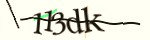

In [17]:
img_name = files[3]
img = cv2.imread(img_name, cv2.IMREAD_COLOR_RGB)
print(img.shape)
Image.fromarray(img)

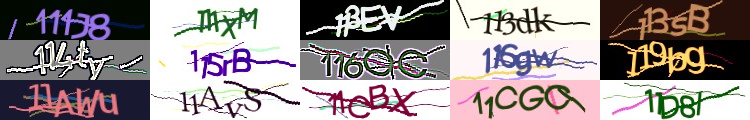

In [19]:
idx = 0
rows = []
for r in range(3):
    cols = []
    for c in range(5):
        cols.append(cv2.imread(files[idx], cv2.IMREAD_COLOR_RGB))
        idx += 1
    rows.append(np.hstack(cols))
img = np.vstack(rows)
Image.fromarray(img)

# Text generation

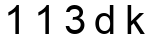

In [25]:
text_img = Image.new("L", (150, 40), "white")
draw = ImageDraw.Draw(text_img)
font = ImageFont.truetype("Arial.ttf", 40)
# draw each character in the center of the cell
for (i, c) in enumerate(img_name.stem):
    draw.text((15 + 30*i, 20), c, fill="black", 
              anchor="mm", font=font)
text_img

In [29]:
np_img = np.array(text_img)
np_img.shape

(40, 150)

# Add the blur to the image

In [30]:
blur_transform = A.GaussianBlur(p=1.0)

In [31]:
blurred_img = blur_transform(image=np_img)['image']

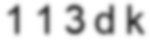

In [32]:
Image.fromarray(blurred_img)

In [33]:
import data_captcha

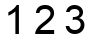

In [34]:
data_captcha.make_target_image("123")